In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales_data = pd.read_csv("vgsales.csv")


In [78]:
sales_data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [79]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [80]:
sales_data.describe()


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Data Cleaning

In [81]:
sales_data.isnull().sum()
sales_data = sales_data.dropna()

The dataset contained missing values in the Year and Publisher columns. Since these represented a small percentage of the data, I removed those rows using dropna() to ensure consistent analysis.

In [82]:
sales_data.duplicated().sum()

np.int64(0)

No duplicates found in data

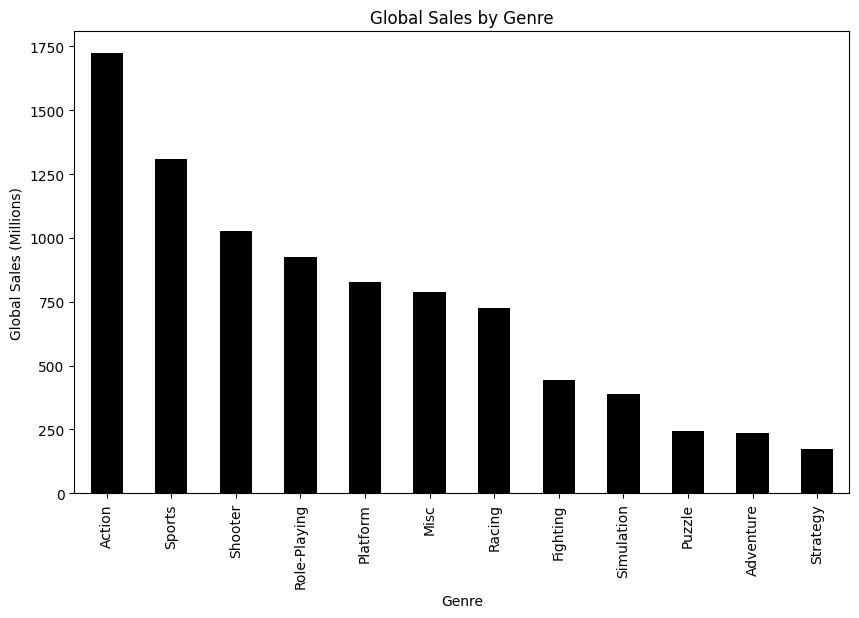

In [83]:
genres_sales=sales_data.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
genres_sales
genres_sales.plot(
    kind="bar",
    figsize=(10,6),
    color="black"
)

plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.title("Global Sales by Genre")
plt.show()

Action games generated the highest global sales.

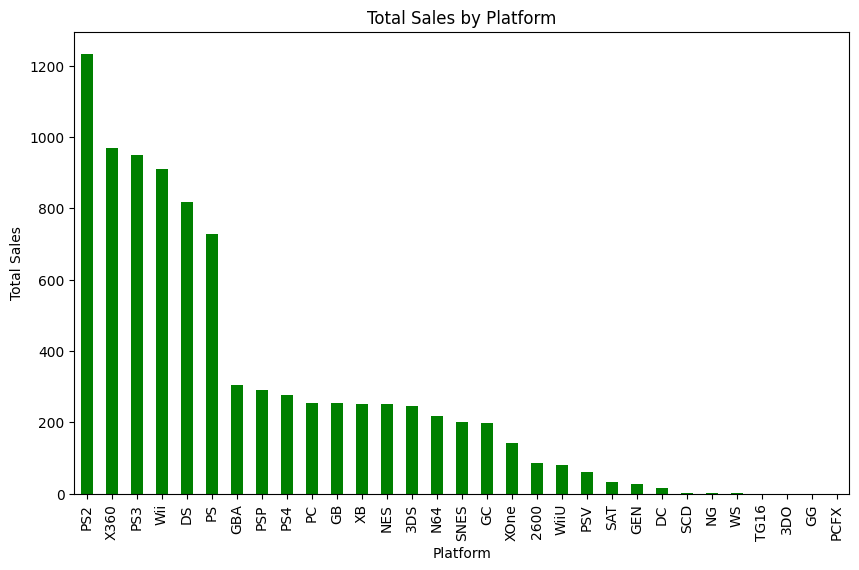

In [84]:
famous_platform=sales_data.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
famous_platform.plot(kind='bar',figsize=(10,6),color='green')
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.title('Total Sales by Platform')
plt.show()

PS2 dominated the market

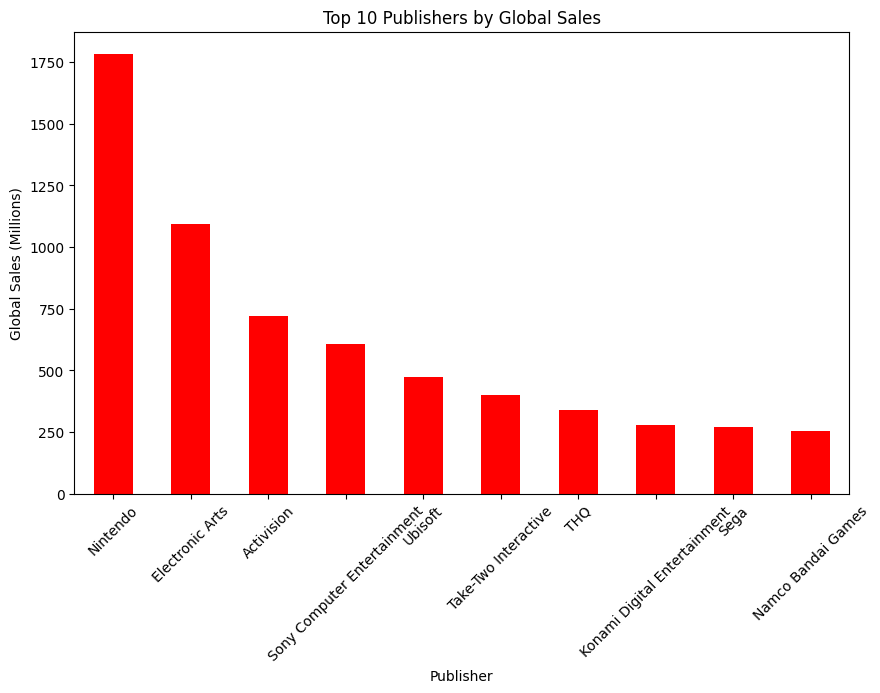

In [85]:
publisher_sales=sales_data.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)
publisher_sales.plot(
    kind="bar",
    figsize=(10,6),
    color="red"
)

plt.xlabel("Publisher")
plt.ylabel("Global Sales (Millions)")
plt.title("Top 10 Publishers by Global Sales")
plt.xticks(rotation=45)
plt.show()

Nintendo generated the highest global sales among all publishers, followed by Electronic Arts and Activision.

Minimum Sales: 0.05 and Minimum Sales Year: 2017.0
Maximum Sales: 678.90 and Maximum Sales Year: 2008.0


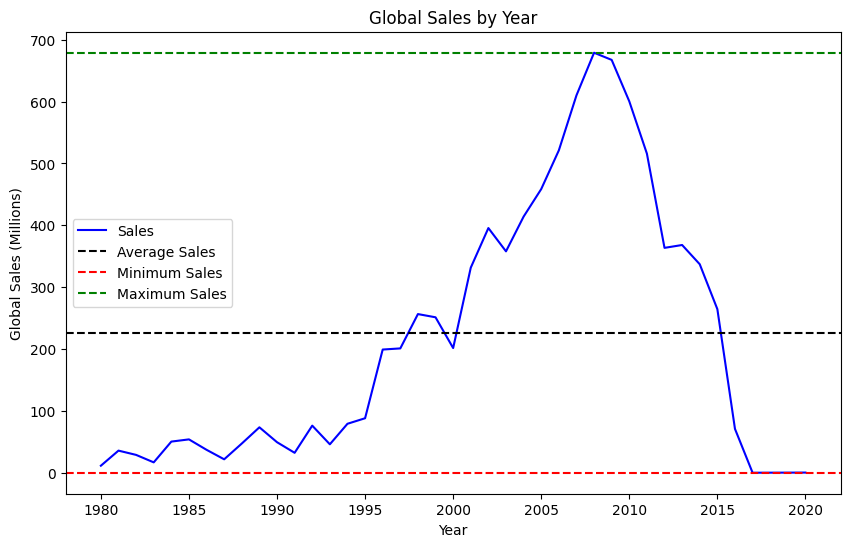

Average Sales: 225.95


In [86]:
# Convert to DataFrame
salesByYear = sales_data.groupby("Year")["Global_Sales"].sum().reset_index()
salesByYear.rename(columns={"Global_Sales": "Sales"}, inplace=True)


salesByYear.plot(
    x="Year",
    y="Sales",
    kind="line",
    figsize=(10,6),
    color="blue"
)


min_sales = salesByYear["Sales"].min()
max_sales = salesByYear["Sales"].max()

min_year = salesByYear.loc[salesByYear["Sales"].idxmin(), "Year"]
max_year = salesByYear.loc[salesByYear["Sales"].idxmax(), "Year"]

print(f"Minimum Sales: {min_sales:.2f} and Minimum Sales Year: {min_year}")
print(f"Maximum Sales: {max_sales:.2f} and Maximum Sales Year: {max_year}")


mean_sales = salesByYear["Sales"].mean()
plt.axhline(y=mean_sales, color="black", linestyle="--", label="Average Sales")
plt.axhline(y=min_sales, color="red", linestyle="--", label="Minimum Sales")
plt.axhline(y=max_sales, color="green", linestyle="--", label="Maximum Sales")

plt.legend()
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.title("Global Sales by Year")
plt.show()

print(f"Average Sales: {mean_sales:.2f}")


Maximum Sales happened in 2008 and Minimum Sales Happend in 2017

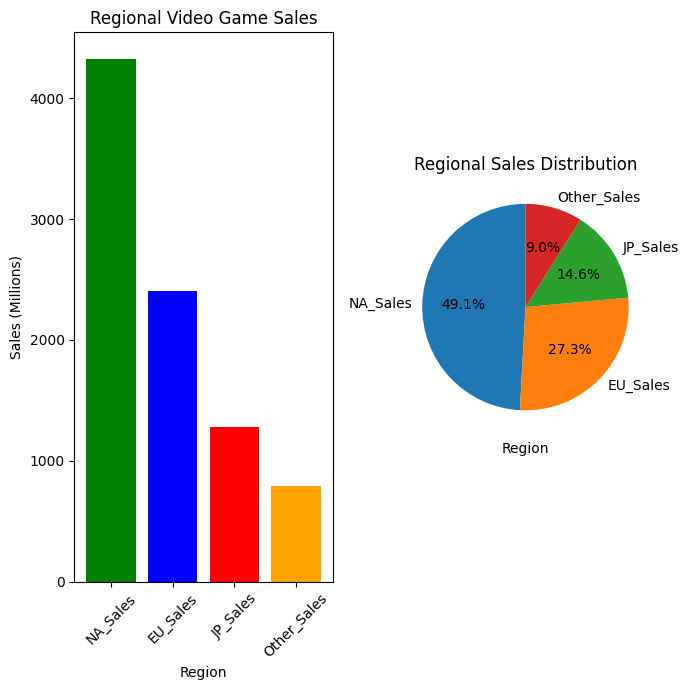

In [87]:
regional_sales = sales_data[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum()

fig,ax=plt.subplots(1,2,figsize=(14,6))

ax[0].bar(
    regional_sales.index,
    regional_sales.values,
    color=["green", "blue", "red", "orange"]
)
ax[0].set_title("Regional Video Game Sales")
ax[0].set_xlabel("Region")
ax[0].set_ylabel("Sales (Millions)")
ax[0].tick_params(axis="x", rotation=45)

# Corrected lines
ax[1].set_title("Regional Video Game Sales")
ax[1].set_xlabel("Region")
ax[1].set_ylabel("Sales (Millions)")

regional_sales.plot(
    kind="pie",
    figsize=(7,7),
    autopct="%1.1f%%",
    startangle=90,
    ax=ax[1] # Plotting on the second subplot
)

ax[1].set_ylabel("") # Set y-label for pie chart to empty
ax[1].set_title("Regional Sales Distribution")

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

North America generated the highest video game sales, followed by Europe. Japan and other regions contributed a smaller share of total global sales.

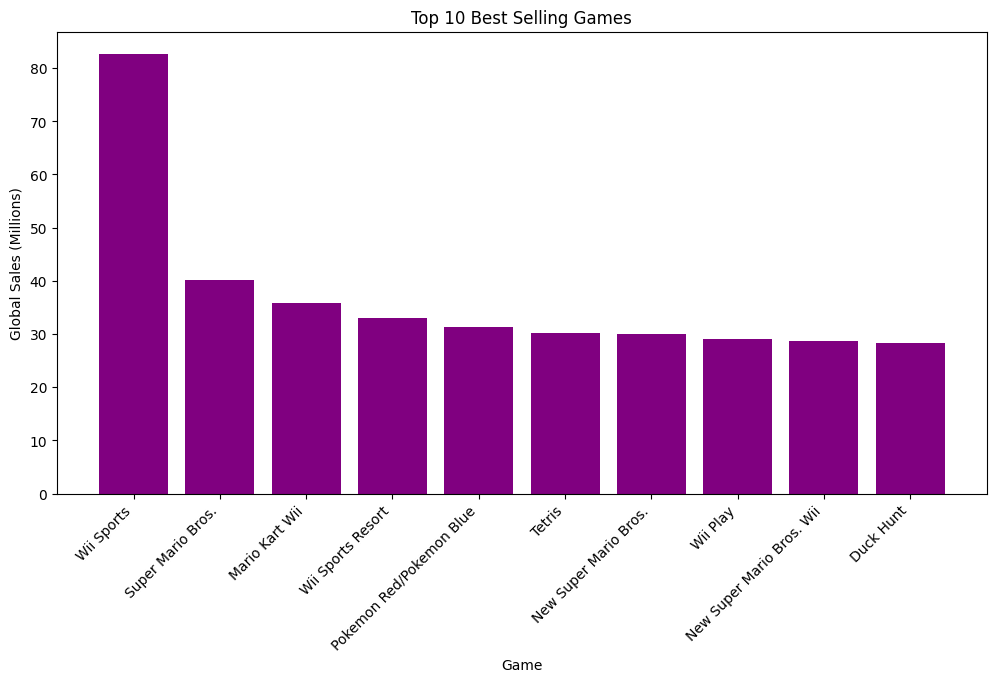

In [88]:
top_games = (
    sales_data
    .sort_values("Global_Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(top_games["Name"], top_games["Global_Sales"], color="purple")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Game")
plt.ylabel("Global Sales (Millions)")
plt.title("Top 10 Best Selling Games")
plt.show()

Wii Sports dominates global sales, significantly outperforming every other title in the dataset.

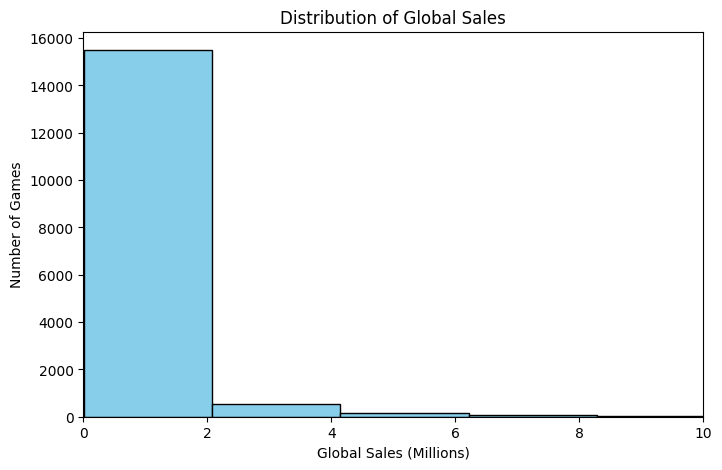

In [89]:
plt.figure(figsize=(8,5))

plt.hist(
    sales_data["Global_Sales"],
    bins=40,
    color="skyblue",
    edgecolor="black"
)

plt.xlim(0,10)

plt.xlabel("Global Sales (Millions)")
plt.ylabel("Number of Games")
plt.title("Distribution of Global Sales")
plt.show()

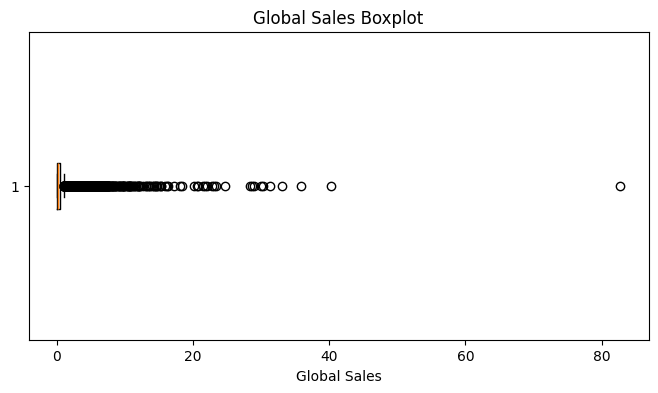

In [90]:
plt.figure(figsize=(8,4))

plt.boxplot(sales_data["Global_Sales"], vert=False)

plt.title("Global Sales Boxplot")
plt.xlabel("Global Sales")
plt.show()

In [91]:
print("Mean:", sales_data["Global_Sales"].mean())
print("Median:", sales_data["Global_Sales"].median())
print("Variance:", sales_data["Global_Sales"].var())
print("Standard Deviation:", sales_data["Global_Sales"].std())

Mean: 0.5409103185808114
Median: 0.17
Variance: 2.4565688029452266
Standard Deviation: 1.5673445067837597


Standard deviation is about three times the mean means the data has a wide spread with some very large values.

Those large values correspond to genuine blockbuster games, which is why the boxplot shows many outliers.

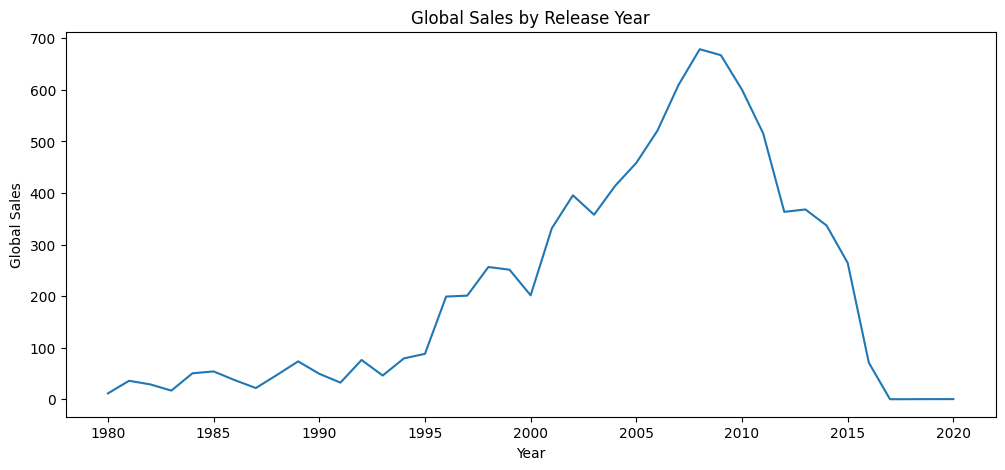

In [92]:
year_sales = sales_data.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(12,5))

year_sales.plot()

plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.title("Global Sales by Release Year")

plt.show()


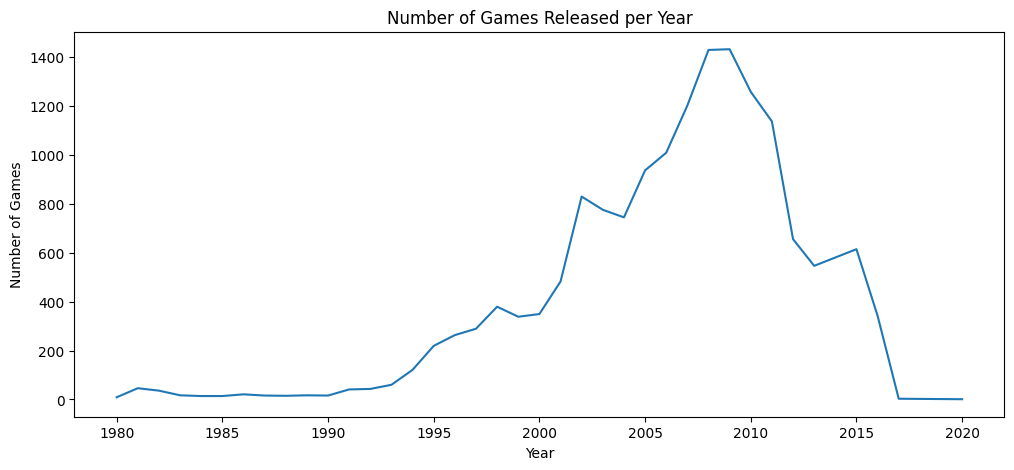

In [93]:
games_per_year = sales_data.groupby("Year")["Name"].count()

plt.figure(figsize=(12,5))

games_per_year.plot()

plt.title("Number of Games Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.show()

"Global video game sales increased steadily from the late 1990s, peaked around 2008–2009, and then declined. The sharp decline after 2016 is likely influenced by the dataset containing fewer games for recent years."

In [94]:
X = sales_data[["Platform", "Genre", "Publisher", "Year"]]

y = sales_data["Global_Sales"]

In [95]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ["Platform", "Genre", "Publisher"]
        )
    ],
    remainder="passthrough"
)

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", DecisionTreeRegressor(random_state=42))
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Platform', 'Genre',
                                                   'Publisher'])])),
                ('tree', DecisionTreeRegressor(random_state=42))])

In [98]:
predictions = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))

MAE: 0.5675953474685569
R²: -0.0918348923206933


In [99]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,0.57,0.488421
1,0.07,0.030000
2,0.19,0.107143
3,0.67,0.020000
4,0.22,0.050000
5,0.11,0.270000
6,0.17,0.170000
7,0.13,0.040000
8,0.02,0.010000
9,0.21,0.140000


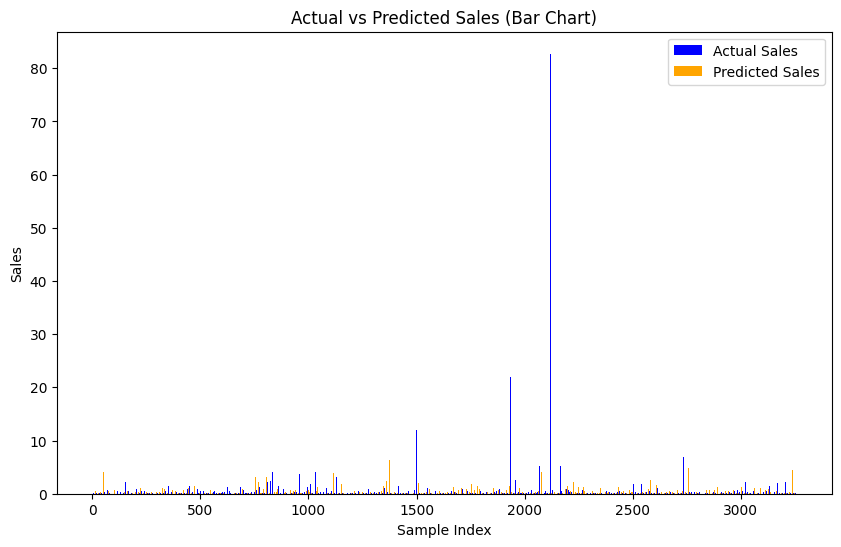

In [105]:
plt.figure(figsize=(10,6))

x = np.arange(len(comparison)) # x-coordinates for the bars
width = 0.4 # Width of the bars

# Actual Sales bars
plt.bar(x - width/2, comparison["Actual Sales"], width, label="Actual Sales", color="blue")

# Predicted Sales bars
plt.bar(x + width/2, comparison["Predicted Sales"], width, label="Predicted Sales", color="orange")

plt.xlabel("Sample Index")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (Bar Chart)")
plt.legend()
plt.show()

In [101]:
tree = model.named_steps["tree"]

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
571,remainder__Year,0.464384
376,cat__Publisher_Nintendo,0.116883
38,cat__Genre_Role-Playing,0.071468
39,cat__Genre_Shooter,0.031751
35,cat__Genre_Platform,0.024776
31,cat__Genre_Action,0.024448
37,cat__Genre_Racing,0.017902
34,cat__Genre_Misc,0.017772
17,cat__Platform_PS3,0.015653
33,cat__Genre_Fighting,0.012214


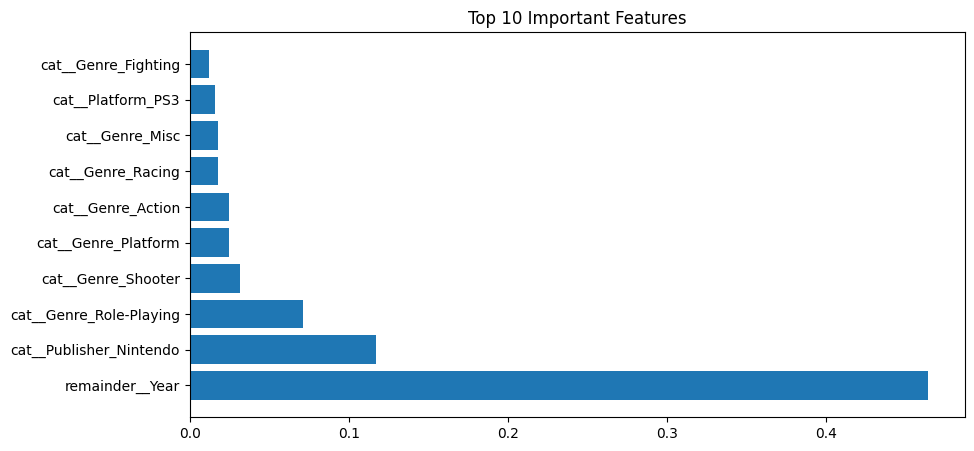

In [102]:
top = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Top 10 Important Features")

plt.show()